# 🔬 Fine-Tuning para Detecção de Code Smells — Treinos Separados

**Modelos:** CodeBERT (`microsoft/codebert-base`), CodeT5 (`Salesforce/codet5-small`) e GraphCodeBERT (`microsoft/graphcodebert-base`)  
**Datasets:** `data-class-MLCQ.csv` e `feature-envy-MLCQ.csv` — treinados **separadamente**  
**Tarefa:** Classificação Binária — *Code Smell* (1) vs *Código Normal* (0)  
**Divisão:** 70% treino / 10% validação / 20% teste (estratificada)  
> ⚠️ O conjunto de **validação** é usado **apenas** para selecionar o melhor checkpoint durante o treino (early stopping por F1).  
> O conjunto de **teste** permanece completamente isolado e só é avaliado após o fim do treino.

---
### 🗺️ Mapa de Experimentos
| Experimento | Modelo          | Dataset       |
|-------------|-----------------|---------------|
| EXP-1       | CodeBERT        | Data Class    |
| EXP-2       | CodeBERT        | Feature Envy  |
| EXP-3       | CodeT5          | Data Class    |
| EXP-4       | CodeT5          | Feature Envy  |
| EXP-5       | GraphCodeBERT   | Data Class    |
| EXP-6       | GraphCodeBERT   | Feature Envy  |


## 1. Instalação de Dependências

In [3]:
%%capture
!pip install transformers==4.40.0 datasets scikit-learn pandas numpy matplotlib seaborn torch accelerate -q

## 2. Importações

In [4]:
import os, re, json, random, warnings, copy
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    RobertaTokenizer,
    RobertaForSequenceClassification,
    get_linear_schedule_with_warmup,
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, matthews_corrcoef,
    confusion_matrix, classification_report, roc_curve,
)

print('✅ Imports OK')
print(f'🔥 PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

✅ Imports OK
🔥 PyTorch 2.10.0+cu128 | CUDA: True
   GPU: Tesla T4


## 3. Configurações Globais

In [5]:
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed()

CONFIG = {
    # ── Caminhos ──────────────────────────────────────────
    'data_class_path'   : '/kaggle/input/datasets/rafaelstc/mlcqcodesmellsdataset/data-class-MLCQ.csv',
    'feature_envy_path' : '/kaggle/input/datasets/rafaelstc/mlcqcodesmellsdataset/feature-envy-MLCQ.csv',
    'output_dir'        : '/kaggle/working/',

    # ── Dados ─────────────────────────────────────────────
    # Divisão: 70% treino | 10% validação | 20% teste
    'test_size'         : 0.20,   # 20% do total → teste
    'val_size'          : 0.125,  # 12.5% dos 80% restantes → 10% do total → validação
    'max_length'        : 512,

    # ── Treino ────────────────────────────────────────────
    'batch_size'        : 16,
    'num_epochs'        : 15,
    'learning_rate'     : 2e-5,
    'weight_decay'      : 0.01,
    'warmup_ratio'      : 0.10,
    'grad_clip'         : 1.0,

    # ── Modelos ───────────────────────────────────────────
    'codebert_name'     : 'microsoft/codebert-base',
    'codet5_name'       : 'Salesforce/codet5-small',
    'num_labels'        : 2,
}

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Paleta de cores por experimento
EXP_COLORS = {
    'CodeBERT × Data Class'   : '#1565C0',
    'CodeBERT × Feature Envy' : '#42A5F5',
    'CodeT5 × Data Class'     : '#E65100',
    'CodeT5 × Feature Envy'   : '#FFA726',
}

print(f'⚙️  Dispositivo : {DEVICE}')
print(f'📐 max_length  : {CONFIG["max_length"]}  |  batch: {CONFIG["batch_size"]}  |  epochs: {CONFIG["num_epochs"]}')
print(f'📊 Divisão     : 70% treino / 10% validação / 20% teste')


⚙️  Dispositivo : cuda
📐 max_length  : 512  |  batch: 16  |  epochs: 15
📊 Divisão     : 70% treino / 10% validação / 20% teste


## 4. Carregamento

In [6]:
def load_and_clean(path: str, smell_type: str) -> pd.DataFrame:
    df = pd.read_csv(path,sep = ';')
    assert 'method'   in df.columns, f"'method' não encontrado em {path}"
    assert 'severity' in df.columns, f"'severity' não encontrado em {path}"
    df.dropna(subset=['method','severity'], inplace=True)
    df['severity']   = df['severity'].astype(int)
    df['method']     = df['method'].astype(str).str.strip()
    df['smell_type'] = smell_type
    df = df[df['method'].str.len() > 0].reset_index(drop=True)
    return df

df_dc = load_and_clean(CONFIG['data_class_path'],   'data_class')
df_fe = load_and_clean(CONFIG['feature_envy_path'], 'feature_envy')

DATASETS = {
    'Data Class'   : df_dc,
    'Feature Envy' : df_fe,
}

print('═' * 52)
for name, df in DATASETS.items():
    n0 = (df['severity']==0).sum()
    n1 = (df['severity']==1).sum()
    print(f'  {name:<14}: {len(df):>6,} exemplos  |  Normal={n0:,}  Smell={n1:,}')
print('═' * 52)

════════════════════════════════════════════════════
  Data Class    :  2,159 exemplos  |  Normal=1,875  Smell=284
  Feature Envy  :  2,242 exemplos  |  Normal=2,176  Smell=66
════════════════════════════════════════════════════


## 5. Utilitários — Dataset, Treino e Avaliação

In [7]:
# ── Pré-processamento ─────────────────────────────────────────
def preprocess_code(code: str) -> str:
    code = re.sub(r'/\*.*?\*/', ' ', code, flags=re.DOTALL)
    code = re.sub(r'//[^\n]*', ' ', code)
    code = re.sub(r'\s+', ' ', code)
    return code.strip()


# ── Dataset PyTorch ───────────────────────────────────────────
class CodeSmellDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.encodings = tokenizer(
            list(texts), truncation=True,
            padding='max_length', max_length=max_length,
            return_tensors='pt',
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item


# ── Divisão de dados: 70% treino | 10% validação | 20% teste ─
def split_dataset(df: pd.DataFrame):
    """
    Retorna (X_tr, X_val, X_te, y_tr, y_val, y_te).

    Estratégia:
      1. Separa 20% como teste (estratificado).
      2. Do restante (80%), separa val_size=12.5% como validação
         → equivale a 10% do total original.
      Resultado final: 70 / 10 / 20.
    """
    df = df.copy()
    df['method_clean'] = df['method'].apply(preprocess_code)
    X, y = df['method_clean'].values, df['severity'].values

    # 1ª divisão: treino+val vs. teste
    X_trainval, X_te, y_trainval, y_te = train_test_split(
        X, y, test_size=CONFIG['test_size'],
        random_state=SEED, stratify=y
    )

    # 2ª divisão: treino vs. validação
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_trainval, y_trainval,
        test_size=CONFIG['val_size'],   # 12.5% de 80% = 10% do total
        random_state=SEED, stratify=y_trainval
    )

    print(f'   Treino    : {len(X_tr):,}  (Normal={sum(y_tr==0):,} | Smell={sum(y_tr==1):,})')
    print(f'   Validação : {len(X_val):,}  (Normal={sum(y_val==0):,} | Smell={sum(y_val==1):,})')
    print(f'   Teste     : {len(X_te):,}  (Normal={sum(y_te==0):,} | Smell={sum(y_te==1):,})')
    return X_tr, X_val, X_te, y_tr, y_val, y_te


# ── Métricas ─────────────────────────────────────────────────
def compute_metrics(y_true, y_pred, y_prob=None):
    m = {
        'accuracy'    : accuracy_score(y_true, y_pred),
        'precision'   : precision_score(y_true, y_pred, zero_division=0),
        'recall'      : recall_score(y_true, y_pred, zero_division=0),
        'f1'          : f1_score(y_true, y_pred, zero_division=0),
        'f1_macro'    : f1_score(y_true, y_pred, average='macro',    zero_division=0),
        'f1_weighted' : f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'mcc'         : matthews_corrcoef(y_true, y_pred),
    }
    if y_prob is not None:
        try:    m['roc_auc'] = roc_auc_score(y_true, y_prob)
        except: m['roc_auc'] = float('nan')
    return m


# ── Loop de treino ────────────────────────────────────────────
def train_model(model, train_loader, val_loader, exp_label, y_train):
    """
    Treina o modelo e seleciona o melhor checkpoint pelo F1 no
    conjunto de VALIDAÇÃO (val_loader), que é distinto do teste.
    """
    model.to(DEVICE)

    # ── Class weights para lidar com desbalanceamento ──────────
    counts  = np.bincount(y_train)
    weights = torch.tensor(len(y_train) / (2 * counts), dtype=torch.float).to(DEVICE)
    loss_fn = torch.nn.CrossEntropyLoss(weight=weights)
    print(f'  ⚖️  Class weights: Normal={weights[0]:.3f} | Smell={weights[1]:.3f}')
    # ──────────────────────────────────────────────────────────

    optimizer = AdamW(model.parameters(),
                      lr=CONFIG['learning_rate'],
                      weight_decay=CONFIG['weight_decay'])
    total_steps  = len(train_loader) * CONFIG['num_epochs']
    warmup_steps = int(total_steps * CONFIG['warmup_ratio'])
    scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

    history = {'train_loss': [], 'val_loss': [], 'val_f1': []}
    best_f1, best_state = 0.0, None

    for epoch in range(CONFIG['num_epochs']):
        # ── Treino ────────────────────────────────────────────
        model.train()
        total_tr_loss = 0
        for step, batch in enumerate(train_loader):
            batch   = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            loss    = loss_fn(outputs.logits, batch['labels'])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['grad_clip'])
            optimizer.step(); scheduler.step(); optimizer.zero_grad()
            total_tr_loss += loss.item()
            if (step + 1) % 50 == 0:
                print(f'  [{exp_label}] Ep {epoch+1} | Step {step+1}/{len(train_loader)} '
                      f'| Loss {total_tr_loss/(step+1):.4f}')

        avg_tr = total_tr_loss / len(train_loader)

        # ── Validação (conjunto separado, nunca visto no teste) ─
        model.eval()
        total_val_loss = 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in val_loader:          # ← val_loader exclusivo
                batch   = {k: v.to(DEVICE) for k, v in batch.items()}
                outputs = model(**batch)
                total_val_loss += loss_fn(outputs.logits, batch['labels']).item()
                preds  = torch.argmax(outputs.logits, dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(batch['labels'].cpu().numpy())

        avg_val = total_val_loss / len(val_loader)
        val_f1  = f1_score(all_labels, all_preds, zero_division=0)

        history['train_loss'].append(avg_tr)
        history['val_loss'].append(avg_val)
        history['val_f1'].append(val_f1)

        star = ''
        if val_f1 > best_f1:
            best_f1    = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            star = '  ✨ melhor ValF1!'

        print(f'  [{exp_label}] Ep {epoch+1}/{CONFIG["num_epochs"]} '
              f'| TrLoss {avg_tr:.4f} | ValLoss {avg_val:.4f} | ValF1 {val_f1:.4f}{star}')

    # Restaura o melhor estado (selecionado pelo val F1)
    if best_state:
        model.load_state_dict(best_state)
    model.to(DEVICE)
    print(f'✅ [{exp_label}] Concluído — melhor ValF1 (validação): {best_f1:.4f}\n')
    return model, history


# ── Avaliação no conjunto de teste ───────────────────────────
def evaluate_model(model, test_loader):
    """Avalia o modelo no conjunto de TESTE (completamente isolado do treino)."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in test_loader:
            batch   = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            probs   = torch.softmax(outputs.logits, dim=1)[:,1].cpu().numpy()
            preds   = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(batch['labels'].cpu().numpy())
            all_probs.extend(probs)
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


# ── Painel de resultados individuais ─────────────────────────
def plot_experiment(history, y_true, y_pred, y_prob, exp_label, color, save_path):
    fig = plt.figure(figsize=(20, 12))
    fig.suptitle(f'Resultados — {exp_label}', fontsize=14, fontweight='bold')
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

    # Curvas de treino
    ax1 = fig.add_subplot(gs[0, 0])
    epochs = range(1, len(history['train_loss']) + 1)
    ax1.plot(epochs, history['train_loss'], 'o-', color=color, linewidth=2, label='Train Loss')
    ax1.plot(epochs, history['val_loss'],   's--', color=color, alpha=0.5, linewidth=2, label='Val Loss')
    ax1_r = ax1.twinx()
    ax1_r.plot(epochs, history['val_f1'], '^:', color='green', linewidth=2, label='Val F1')
    ax1_r.set_ylabel('Val F1 (validação)', color='green')
    ax1_r.tick_params(axis='y', labelcolor='green')
    lines1, lbl1 = ax1.get_legend_handles_labels()
    lines2, lbl2 = ax1_r.get_legend_handles_labels()
    ax1.legend(lines1+lines2, lbl1+lbl2, fontsize=8, loc='upper right')
    ax1.set_title('Curva de Treino (Loss e Val F1)', fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.grid(True, alpha=0.3)

    # Matriz de Confusão
    ax2 = fig.add_subplot(gs[0, 1])
    cm      = confusion_matrix(y_true, y_pred)
    cm_pct  = cm.astype(float) / cm.sum(axis=1)[:,np.newaxis] * 100
    annot   = np.array([[f'{cm[i,j]}\n({cm_pct[i,j]:.1f}%)' for j in range(2)] for i in range(2)])
    cmap    = plt.cm.Blues if 'CodeBERT' in exp_label else plt.cm.Oranges
    sns.heatmap(cm, annot=annot, fmt='', ax=ax2, cmap=cmap,
                xticklabels=['Normal','Smell'], yticklabels=['Normal','Smell'],
                linewidths=0.5, cbar=False, annot_kws={'size':11,'weight':'bold'})
    ax2.set_title('Matriz de Confusão (Teste)', fontweight='bold')
    ax2.set_xlabel('Predito'); ax2.set_ylabel('Real')

    # Curva ROC
    ax3 = fig.add_subplot(gs[0, 2])
    try:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc_val     = roc_auc_score(y_true, y_prob)
        ax3.plot(fpr, tpr, color=color, linewidth=2.5, label=f'AUC = {auc_val:.3f}')
    except Exception:
        pass
    ax3.plot([0,1],[0,1],'k--', linewidth=1)
    ax3.set_title('Curva ROC (Teste)', fontweight='bold')
    ax3.set_xlabel('FPR'); ax3.set_ylabel('TPR')
    ax3.legend(); ax3.grid(True, alpha=0.3)

    # Distribuição das probabilidades previstas
    ax4 = fig.add_subplot(gs[1, 0])
    ax4.hist(y_prob[y_true==0], bins=30, alpha=0.6, color='#4CAF50', label='Normal (real)')
    ax4.hist(y_prob[y_true==1], bins=30, alpha=0.6, color='#F44336', label='Smell (real)')
    ax4.axvline(0.5, color='black', linestyle='--', linewidth=1.5)
    ax4.set_title('Distribuição das Probabilidades (Teste)', fontweight='bold')
    ax4.set_xlabel('P(Smell)'); ax4.legend(fontsize=8)

    # Métricas em barras
    ax5 = fig.add_subplot(gs[1, 1])
    metrics = compute_metrics(y_true, y_pred, y_prob)
    met_keys = ['accuracy','precision','recall','f1','f1_macro','mcc']
    met_lbls = ['Accuracy','Precision','Recall','F1','F1 Macro','MCC']
    vals = [metrics[k] for k in met_keys]
    bars = ax5.barh(met_lbls, vals, color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax5.text(v + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{v:.4f}', va='center', fontsize=9)
    ax5.set_xlim(0, 1.15)
    ax5.set_title('Métricas de Classificação (Teste)', fontweight='bold')
    ax5.grid(axis='x', alpha=0.3)

    # Classification report como tabela
    ax6 = fig.add_subplot(gs[1, 2])
    ax6.axis('off')
    report = classification_report(y_true, y_pred,
                                   target_names=['Normal','Smell'],
                                   output_dict=True)
    rows = []
    for cls in ['Normal','Smell','macro avg','weighted avg']:
        r = report.get(cls, {})
        rows.append([cls,
                     f"{r.get('precision',0):.3f}",
                     f"{r.get('recall',0):.3f}",
                     f"{r.get('f1-score',0):.3f}",
                     f"{int(r.get('support',0))}"])
    tbl = ax6.table(cellText=rows,
                    colLabels=['Classe','Prec','Rec','F1','Support'],
                    cellLoc='center', loc='center',
                    bbox=[0.0, 0.1, 1.0, 0.85])
    tbl.auto_set_font_size(False); tbl.set_fontsize(10)
    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_facecolor('#37474F')
            cell.set_text_props(color='white', fontweight='bold')
        elif row % 2 == 0:
            cell.set_facecolor('#ECEFF1')
    ax6.set_title('Classification Report (Teste)', fontweight='bold')

    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    print(f'💾 Painel salvo em {save_path}')
    return metrics


print('✅ Todos os utilitários definidos!')


✅ Todos os utilitários definidos!


---
## 6. EXP-1 — CodeBERT × Data Class

In [8]:
print('═'*55)
print('  🔵 EXP-1 — CodeBERT × Data Class')
print('═'*55)

X_tr, X_val, X_te, y_tr, y_val, y_te = split_dataset(df_dc)

tok_cb = RobertaTokenizer.from_pretrained(CONFIG['codebert_name'])

train_ds = CodeSmellDataset(X_tr,  y_tr,  tok_cb, CONFIG['max_length'])
val_ds   = CodeSmellDataset(X_val, y_val, tok_cb, CONFIG['max_length'])
test_ds  = CodeSmellDataset(X_te,  y_te,  tok_cb, CONFIG['max_length'])

train_dl = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True,  num_workers=0, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0, pin_memory=True)

model_cb_dc = RobertaForSequenceClassification.from_pretrained(
    CONFIG['codebert_name'], num_labels=CONFIG['num_labels'])

# val_dl → seleciona melhor F1 no treino  |  test_dl → avaliação final isolada
model_cb_dc, hist_cb_dc = train_model(model_cb_dc, train_dl, val_dl, 'CodeBERT×DataClass', y_tr)


═══════════════════════════════════════════════════════
  🔵 EXP-1 — CodeBERT × Data Class
═══════════════════════════════════════════════════════
   Treino    : 1,511  (Normal=1,312 | Smell=199)
   Validação : 216  (Normal=188 | Smell=28)
   Teste     : 432  (Normal=375 | Smell=57)


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/codebert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  ⚖️  Class weights: Normal=0.576 | Smell=3.796
  [CodeBERT×DataClass] Ep 1 | Step 50/95 | Loss 0.6974
  [CodeBERT×DataClass] Ep 1/15 | TrLoss 0.6483 | ValLoss 0.4857 | ValF1 0.4522  ✨ melhor ValF1!
  [CodeBERT×DataClass] Ep 2 | Step 50/95 | Loss 0.4301
  [CodeBERT×DataClass] Ep 2/15 | TrLoss 0.4198 | ValLoss 0.3950 | ValF1 0.5974  ✨ melhor ValF1!
  [CodeBERT×DataClass] Ep 3 | Step 50/95 | Loss 0.3807
  [CodeBERT×DataClass] Ep 3/15 | TrLoss 0.4260 | ValLoss 0.4232 | ValF1 0.6479  ✨ melhor ValF1!
  [CodeBERT×DataClass] Ep 4 | Step 50/95 | Loss 0.2757
  [CodeBERT×DataClass] Ep 4/15 | TrLoss 0.2667 | ValLoss 0.6601 | ValF1 0.6769  ✨ melhor ValF1!
  [CodeBERT×DataClass] Ep 5 | Step 50/95 | Loss 0.3065
  [CodeBERT×DataClass] Ep 5/15 | TrLoss 0.2715 | ValLoss 0.6461 | ValF1 0.6197
  [CodeBERT×DataClass] Ep 6 | Step 50/95 | Loss 0.0897
  [CodeBERT×DataClass] Ep 6/15 | TrLoss 0.1311 | ValLoss 0.7912 | ValF1 0.6897  ✨ melhor ValF1!
  [CodeBERT×DataClass] Ep 7 | Step 50/95 | Loss 0.0535
  [CodeB

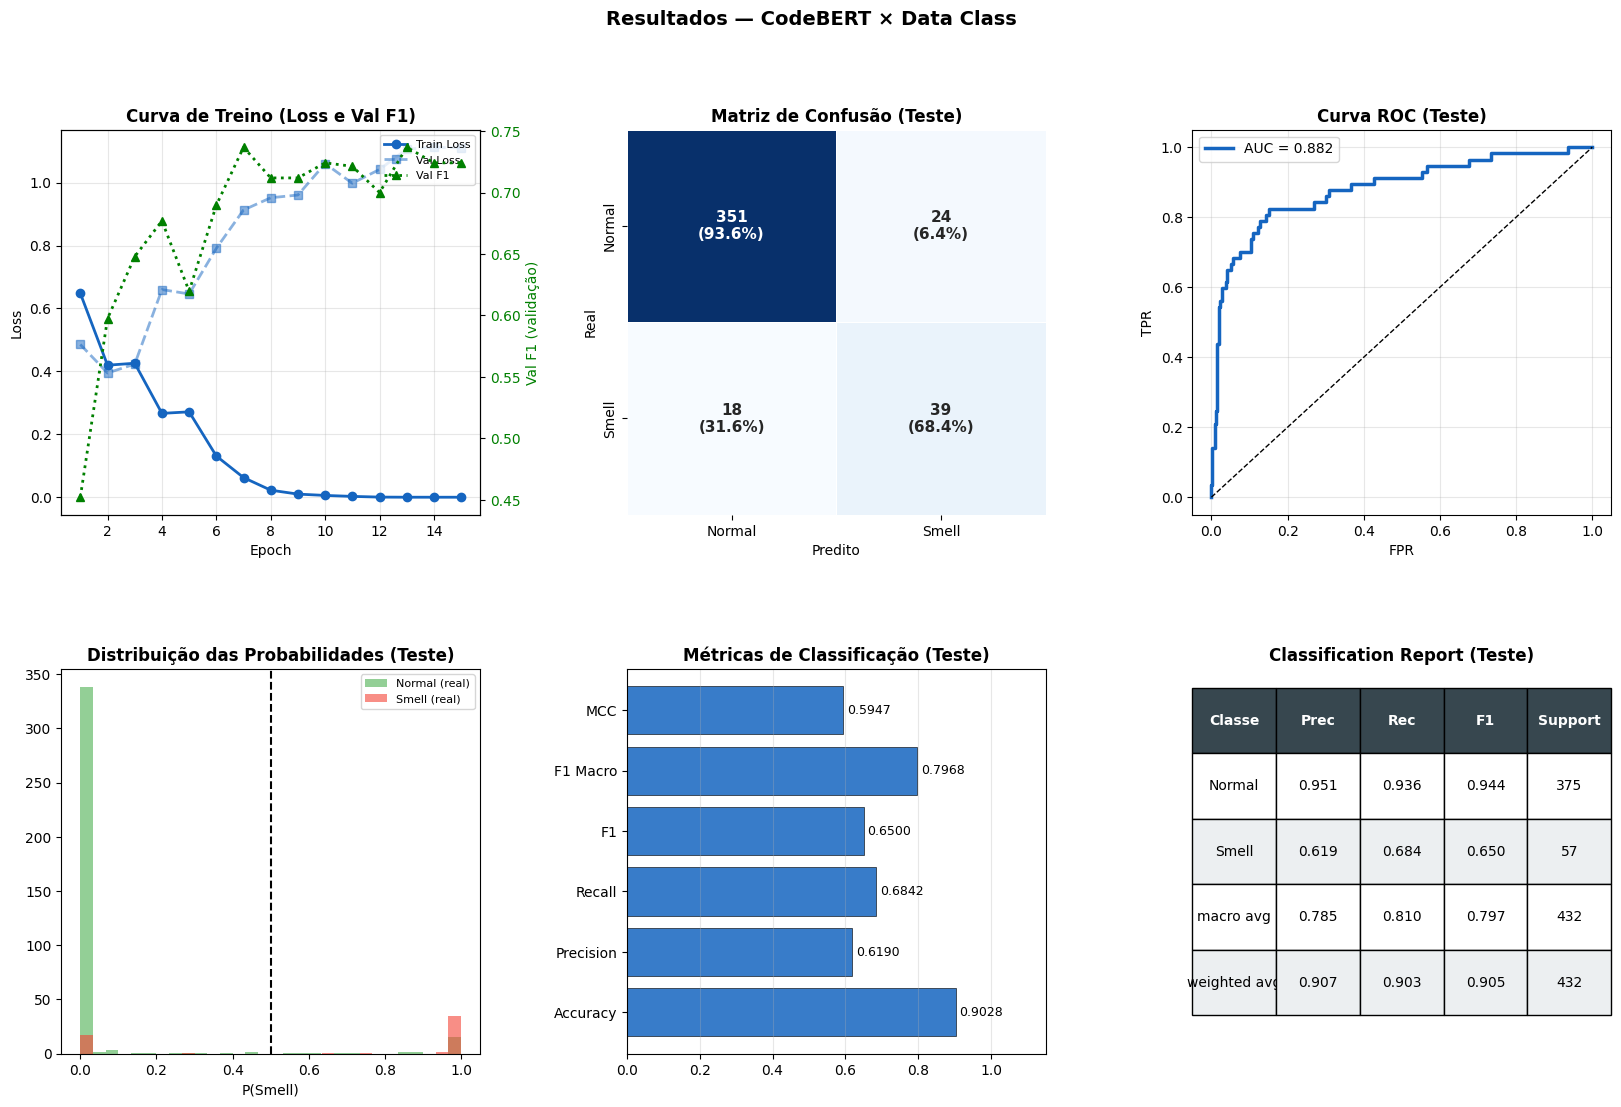

💾 Painel salvo em /kaggle/working/exp1_codebert_dataclass.pdf

📋 Classification Report completo — CodeBERT × Data Class
              precision    recall  f1-score   support

  Normal (0)       0.95      0.94      0.94       375
   Smell (1)       0.62      0.68      0.65        57

    accuracy                           0.90       432
   macro avg       0.79      0.81      0.80       432
weighted avg       0.91      0.90      0.90       432



In [9]:
lbl_cb_dc, pred_cb_dc, prob_cb_dc = evaluate_model(model_cb_dc, test_dl)

metrics_cb_dc = plot_experiment(
    history    = hist_cb_dc,
    y_true     = lbl_cb_dc,
    y_pred     = pred_cb_dc,
    y_prob     = prob_cb_dc,
    exp_label  = 'CodeBERT × Data Class',
    color      = EXP_COLORS['CodeBERT × Data Class'],
    save_path  = f"{CONFIG['output_dir']}exp1_codebert_dataclass.pdf",
)

print('\n📋 Classification Report completo — CodeBERT × Data Class')
print(classification_report(lbl_cb_dc, pred_cb_dc, target_names=['Normal (0)','Smell (1)']))

---
## 7. EXP-2 — CodeBERT × Feature Envy

In [10]:
print('═'*55)
print('  🔷 EXP-2 — CodeBERT × Feature Envy')
print('═'*55)

X_tr, X_val, X_te, y_tr, y_val, y_te = split_dataset(df_fe)

train_ds = CodeSmellDataset(X_tr,  y_tr,  tok_cb, CONFIG['max_length'])
val_ds   = CodeSmellDataset(X_val, y_val, tok_cb, CONFIG['max_length'])
test_ds  = CodeSmellDataset(X_te,  y_te,  tok_cb, CONFIG['max_length'])

train_dl = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True,  num_workers=0, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0, pin_memory=True)

model_cb_fe = RobertaForSequenceClassification.from_pretrained(
    CONFIG['codebert_name'], num_labels=CONFIG['num_labels'])

model_cb_fe, hist_cb_fe = train_model(model_cb_fe, train_dl, val_dl, 'CodeBERT×FeatureEnvy', y_tr)


═══════════════════════════════════════════════════════
  🔷 EXP-2 — CodeBERT × Feature Envy
═══════════════════════════════════════════════════════
   Treino    : 1,568  (Normal=1,522 | Smell=46)
   Validação : 225  (Normal=218 | Smell=7)
   Teste     : 449  (Normal=436 | Smell=13)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/codebert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  ⚖️  Class weights: Normal=0.515 | Smell=17.043
  [CodeBERT×FeatureEnvy] Ep 1 | Step 50/98 | Loss 0.6772
  [CodeBERT×FeatureEnvy] Ep 1/15 | TrLoss 0.6436 | ValLoss 1.2640 | ValF1 0.0000
  [CodeBERT×FeatureEnvy] Ep 2 | Step 50/98 | Loss 0.9851
  [CodeBERT×FeatureEnvy] Ep 2/15 | TrLoss 0.9476 | ValLoss 1.0473 | ValF1 0.0000
  [CodeBERT×FeatureEnvy] Ep 3 | Step 50/98 | Loss 0.9835
  [CodeBERT×FeatureEnvy] Ep 3/15 | TrLoss 0.8984 | ValLoss 1.0498 | ValF1 0.0000
  [CodeBERT×FeatureEnvy] Ep 4 | Step 50/98 | Loss 0.5784
  [CodeBERT×FeatureEnvy] Ep 4/15 | TrLoss 0.6988 | ValLoss 1.5595 | ValF1 0.0000
  [CodeBERT×FeatureEnvy] Ep 5 | Step 50/98 | Loss 0.4323
  [CodeBERT×FeatureEnvy] Ep 5/15 | TrLoss 0.4544 | ValLoss 1.1715 | ValF1 0.1739  ✨ melhor ValF1!
  [CodeBERT×FeatureEnvy] Ep 6 | Step 50/98 | Loss 0.1681
  [CodeBERT×FeatureEnvy] Ep 6/15 | TrLoss 0.1702 | ValLoss 1.8864 | ValF1 0.0000
  [CodeBERT×FeatureEnvy] Ep 7 | Step 50/98 | Loss 0.0158
  [CodeBERT×FeatureEnvy] Ep 7/15 | TrLoss 0.0716 

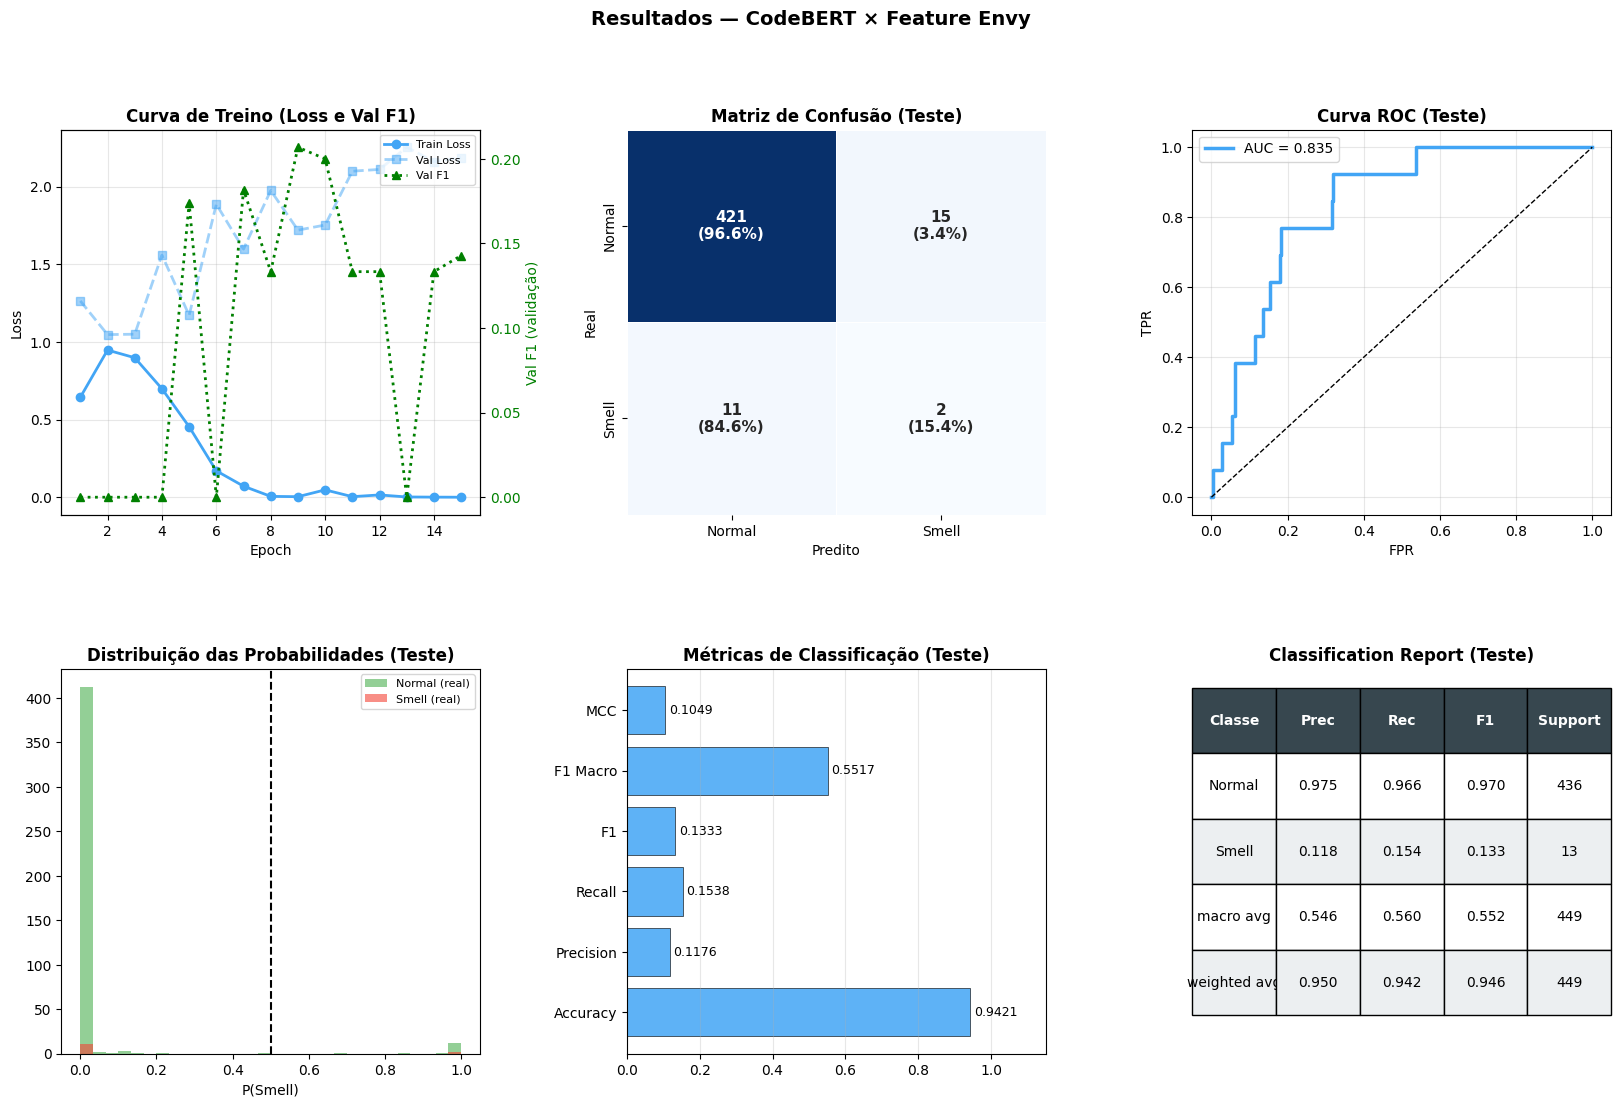

💾 Painel salvo em /kaggle/working/exp2_codebert_featureenvy.pdf

📋 Classification Report completo — CodeBERT × Feature Envy
              precision    recall  f1-score   support

  Normal (0)       0.97      0.97      0.97       436
   Smell (1)       0.12      0.15      0.13        13

    accuracy                           0.94       449
   macro avg       0.55      0.56      0.55       449
weighted avg       0.95      0.94      0.95       449



In [11]:
lbl_cb_fe, pred_cb_fe, prob_cb_fe = evaluate_model(model_cb_fe, test_dl)

metrics_cb_fe = plot_experiment(
    history    = hist_cb_fe,
    y_true     = lbl_cb_fe,
    y_pred     = pred_cb_fe,
    y_prob     = prob_cb_fe,
    exp_label  = 'CodeBERT × Feature Envy',
    color      = EXP_COLORS['CodeBERT × Feature Envy'],
    save_path  = f"{CONFIG['output_dir']}exp2_codebert_featureenvy.pdf",
)

print('\n📋 Classification Report completo — CodeBERT × Feature Envy')
print(classification_report(lbl_cb_fe, pred_cb_fe, target_names=['Normal (0)','Smell (1)']))

---
## 8. EXP-3 — CodeT5 × Data Class

In [12]:
print('═'*55)
print('  🟠 EXP-3 — CodeT5 × Data Class')
print('═'*55)

X_tr, X_val, X_te, y_tr, y_val, y_te = split_dataset(df_dc)

tok_ct = AutoTokenizer.from_pretrained(CONFIG['codet5_name'])

train_ds = CodeSmellDataset(X_tr,  y_tr,  tok_ct, CONFIG['max_length'])
val_ds   = CodeSmellDataset(X_val, y_val, tok_ct, CONFIG['max_length'])
test_ds  = CodeSmellDataset(X_te,  y_te,  tok_ct, CONFIG['max_length'])

train_dl = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True,  num_workers=0, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0, pin_memory=True)

model_ct_dc = AutoModelForSequenceClassification.from_pretrained(
    CONFIG['codet5_name'], num_labels=CONFIG['num_labels'])

model_ct_dc, hist_ct_dc = train_model(model_ct_dc, train_dl, val_dl, 'CodeT5×DataClass', y_tr)


═══════════════════════════════════════════════════════
  🟠 EXP-3 — CodeT5 × Data Class
═══════════════════════════════════════════════════════
   Treino    : 1,511  (Normal=1,312 | Smell=199)
   Validação : 216  (Normal=188 | Smell=28)
   Teste     : 432  (Normal=375 | Smell=57)


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/242M [00:00<?, ?B/s]

Some weights of T5ForSequenceClassification were not initialized from the model checkpoint at Salesforce/codet5-small and are newly initialized: ['classification_head.dense.bias', 'classification_head.dense.weight', 'classification_head.out_proj.bias', 'classification_head.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  ⚖️  Class weights: Normal=0.576 | Smell=3.796
  [CodeT5×DataClass] Ep 1 | Step 50/95 | Loss 0.7855
  [CodeT5×DataClass] Ep 1/15 | TrLoss 0.7803 | ValLoss 0.6279 | ValF1 0.3066  ✨ melhor ValF1!
  [CodeT5×DataClass] Ep 2 | Step 50/95 | Loss 0.5911
  [CodeT5×DataClass] Ep 2/15 | TrLoss 0.5959 | ValLoss 0.5008 | ValF1 0.5373  ✨ melhor ValF1!
  [CodeT5×DataClass] Ep 3 | Step 50/95 | Loss 0.4714
  [CodeT5×DataClass] Ep 3/15 | TrLoss 0.4688 | ValLoss 0.4757 | ValF1 0.4706
  [CodeT5×DataClass] Ep 4 | Step 50/95 | Loss 0.3813
  [CodeT5×DataClass] Ep 4/15 | TrLoss 0.4091 | ValLoss 0.4208 | ValF1 0.6027  ✨ melhor ValF1!
  [CodeT5×DataClass] Ep 5 | Step 50/95 | Loss 0.2949
  [CodeT5×DataClass] Ep 5/15 | TrLoss 0.3896 | ValLoss 0.5456 | ValF1 0.5902
  [CodeT5×DataClass] Ep 6 | Step 50/95 | Loss 0.3033
  [CodeT5×DataClass] Ep 6/15 | TrLoss 0.2961 | ValLoss 0.5505 | ValF1 0.5714
  [CodeT5×DataClass] Ep 7 | Step 50/95 | Loss 0.2578
  [CodeT5×DataClass] Ep 7/15 | TrLoss 0.2467 | ValLoss 0.7828 | ValF

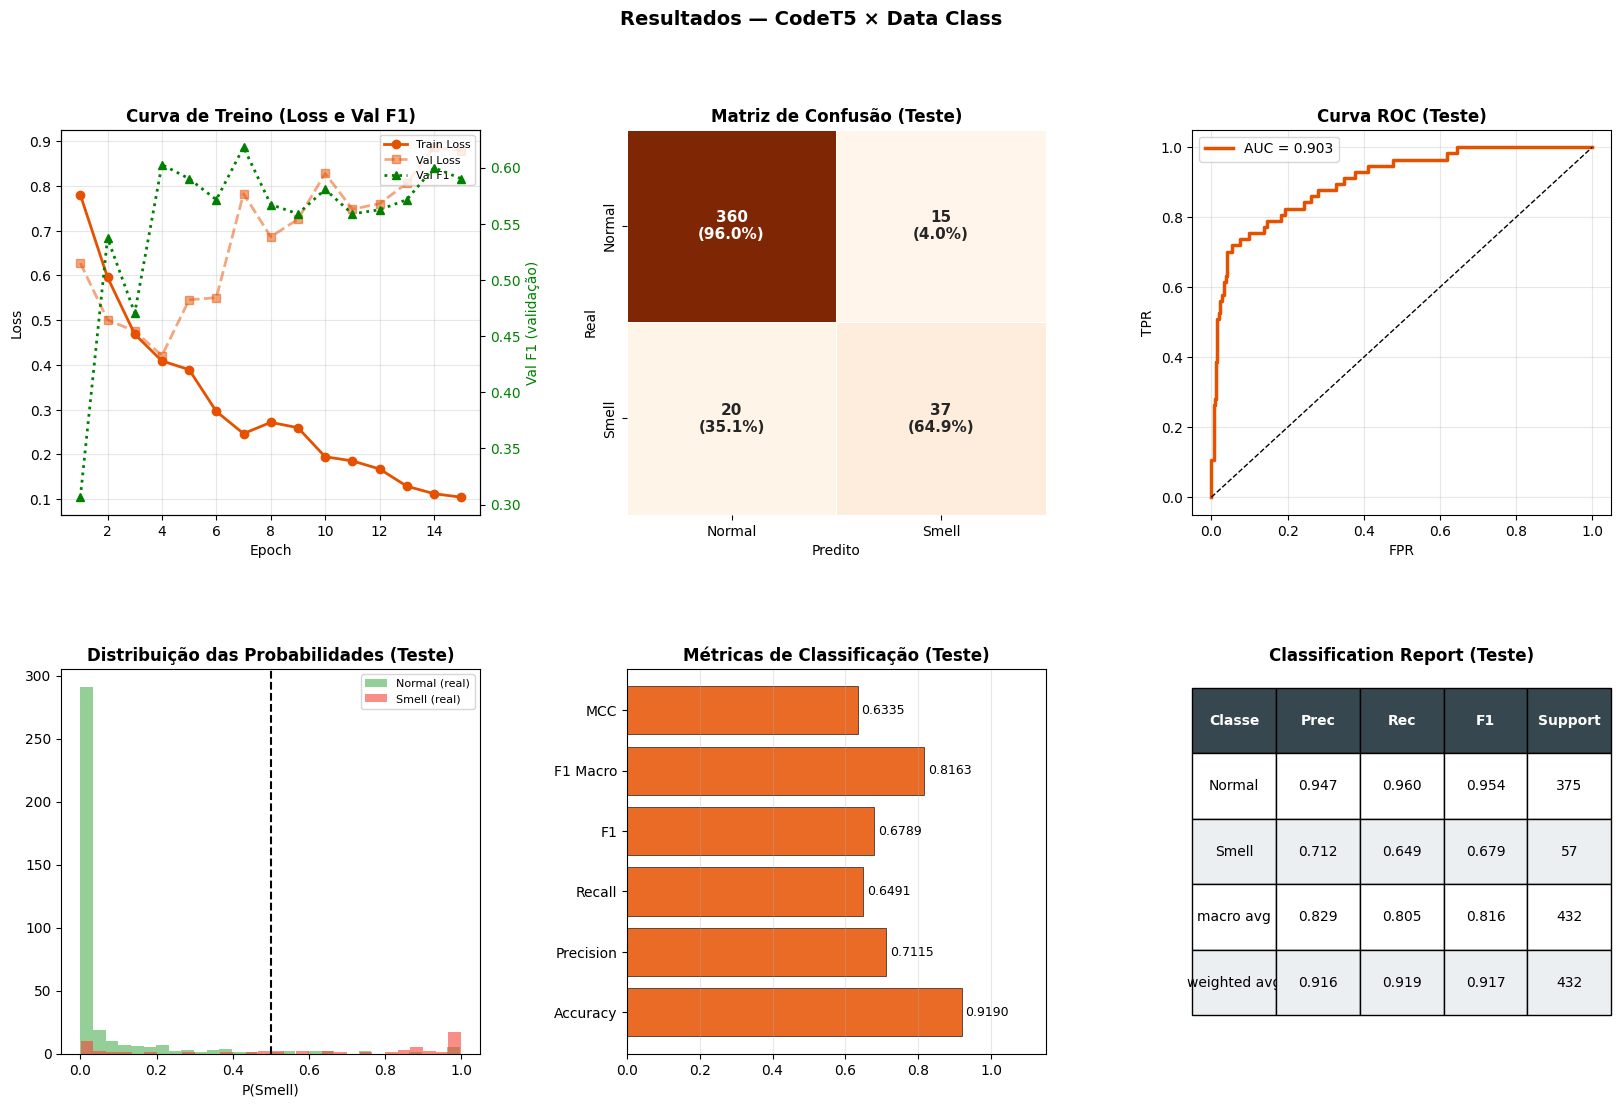

💾 Painel salvo em /kaggle/working/exp3_codet5_dataclass.pdf

📋 Classification Report completo — CodeT5 × Data Class
              precision    recall  f1-score   support

  Normal (0)       0.95      0.96      0.95       375
   Smell (1)       0.71      0.65      0.68        57

    accuracy                           0.92       432
   macro avg       0.83      0.80      0.82       432
weighted avg       0.92      0.92      0.92       432



In [13]:
lbl_ct_dc, pred_ct_dc, prob_ct_dc = evaluate_model(model_ct_dc, test_dl)

metrics_ct_dc = plot_experiment(
    history    = hist_ct_dc,
    y_true     = lbl_ct_dc,
    y_pred     = pred_ct_dc,
    y_prob     = prob_ct_dc,
    exp_label  = 'CodeT5 × Data Class',
    color      = EXP_COLORS['CodeT5 × Data Class'],
    save_path  = f"{CONFIG['output_dir']}exp3_codet5_dataclass.pdf",
)

print('\n📋 Classification Report completo — CodeT5 × Data Class')
print(classification_report(lbl_ct_dc, pred_ct_dc, target_names=['Normal (0)','Smell (1)']))

---
## 9. EXP-4 — CodeT5 × Feature Envy

In [14]:
print('═'*55)
print('  🟡 EXP-4 — CodeT5 × Feature Envy')
print('═'*55)

X_tr, X_val, X_te, y_tr, y_val, y_te = split_dataset(df_fe)

train_ds = CodeSmellDataset(X_tr,  y_tr,  tok_ct, CONFIG['max_length'])
val_ds   = CodeSmellDataset(X_val, y_val, tok_ct, CONFIG['max_length'])
test_ds  = CodeSmellDataset(X_te,  y_te,  tok_ct, CONFIG['max_length'])

train_dl = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True,  num_workers=0, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0, pin_memory=True)

model_ct_fe = AutoModelForSequenceClassification.from_pretrained(
    CONFIG['codet5_name'], num_labels=CONFIG['num_labels'])

model_ct_fe, hist_ct_fe = train_model(model_ct_fe, train_dl, val_dl, 'CodeT5×FeatureEnvy', y_tr)


═══════════════════════════════════════════════════════
  🟡 EXP-4 — CodeT5 × Feature Envy
═══════════════════════════════════════════════════════
   Treino    : 1,568  (Normal=1,522 | Smell=46)
   Validação : 225  (Normal=218 | Smell=7)
   Teste     : 449  (Normal=436 | Smell=13)


Some weights of T5ForSequenceClassification were not initialized from the model checkpoint at Salesforce/codet5-small and are newly initialized: ['classification_head.dense.bias', 'classification_head.dense.weight', 'classification_head.out_proj.bias', 'classification_head.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  ⚖️  Class weights: Normal=0.515 | Smell=17.043
  [CodeT5×FeatureEnvy] Ep 1 | Step 50/98 | Loss 0.7235
  [CodeT5×FeatureEnvy] Ep 1/15 | TrLoss 0.8520 | ValLoss 1.5872 | ValF1 0.0000
  [CodeT5×FeatureEnvy] Ep 2 | Step 50/98 | Loss 1.3464
  [CodeT5×FeatureEnvy] Ep 2/15 | TrLoss 1.2026 | ValLoss 1.4177 | ValF1 0.0000
  [CodeT5×FeatureEnvy] Ep 3 | Step 50/98 | Loss 0.8661
  [CodeT5×FeatureEnvy] Ep 3/15 | TrLoss 1.0496 | ValLoss 0.8475 | ValF1 0.0000
  [CodeT5×FeatureEnvy] Ep 4 | Step 50/98 | Loss 0.7222
  [CodeT5×FeatureEnvy] Ep 4/15 | TrLoss 0.9811 | ValLoss 1.4478 | ValF1 0.0000
  [CodeT5×FeatureEnvy] Ep 5 | Step 50/98 | Loss 1.0740
  [CodeT5×FeatureEnvy] Ep 5/15 | TrLoss 0.9342 | ValLoss 1.5075 | ValF1 0.0000
  [CodeT5×FeatureEnvy] Ep 6 | Step 50/98 | Loss 0.9654
  [CodeT5×FeatureEnvy] Ep 6/15 | TrLoss 0.8991 | ValLoss 1.4076 | ValF1 0.0000
  [CodeT5×FeatureEnvy] Ep 7 | Step 50/98 | Loss 0.5885
  [CodeT5×FeatureEnvy] Ep 7/15 | TrLoss 0.7007 | ValLoss 1.0034 | ValF1 0.0000
  [CodeT5×Fea

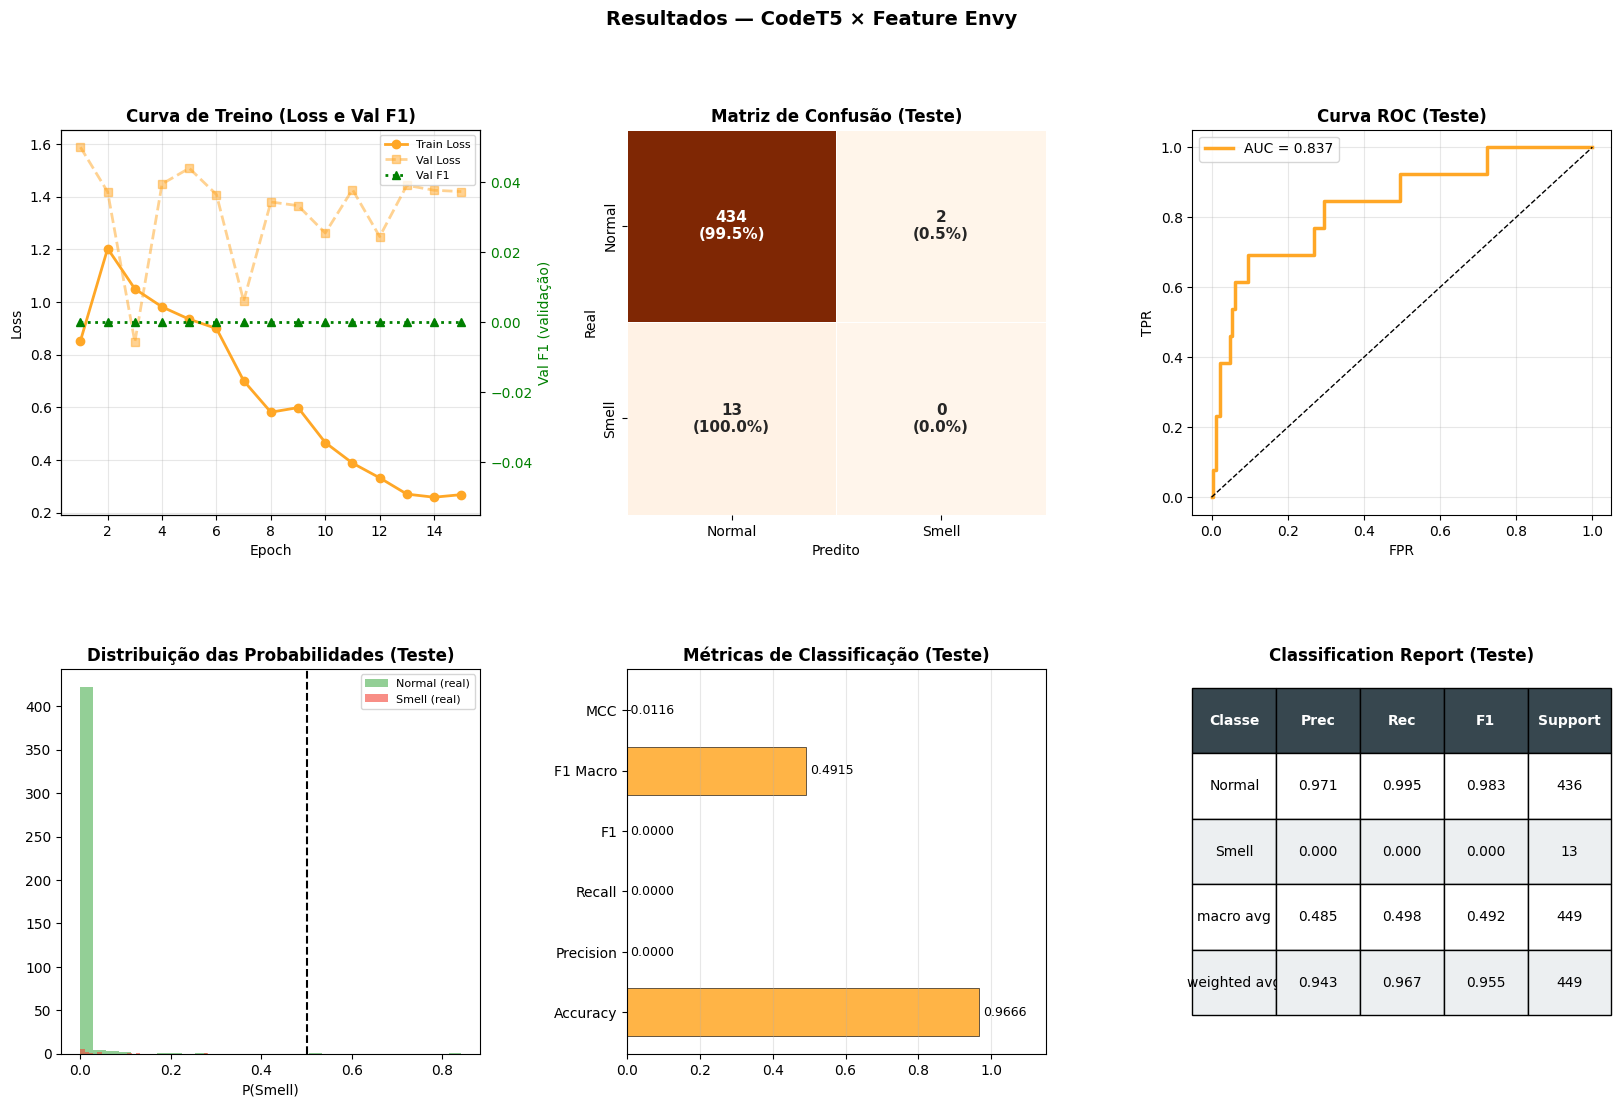

💾 Painel salvo em /kaggle/working/exp4_codet5_featureenvy.pdf

📋 Classification Report completo — CodeT5 × Feature Envy
              precision    recall  f1-score   support

  Normal (0)       0.97      1.00      0.98       436
   Smell (1)       0.00      0.00      0.00        13

    accuracy                           0.97       449
   macro avg       0.49      0.50      0.49       449
weighted avg       0.94      0.97      0.95       449



In [15]:
lbl_ct_fe, pred_ct_fe, prob_ct_fe = evaluate_model(model_ct_fe, test_dl)

metrics_ct_fe = plot_experiment(
    history    = hist_ct_fe,
    y_true     = lbl_ct_fe,
    y_pred     = pred_ct_fe,
    y_prob     = prob_ct_fe,
    exp_label  = 'CodeT5 × Feature Envy',
    color      = EXP_COLORS['CodeT5 × Feature Envy'],
    save_path  = f"{CONFIG['output_dir']}exp4_codet5_featureenvy.pdf",
)

print('\n📋 Classification Report completo — CodeT5 × Feature Envy')
print(classification_report(lbl_ct_fe, pred_ct_fe, target_names=['Normal (0)','Smell (1)']))

---
## 10. EXP-5 — GraphCodeBERT × Data Class


In [16]:
print('═'*58)
print('  🟢 EXP-5 — GraphCodeBERT × Data Class')
print('═'*58)

GRAPHCODEBERT_NAME = 'microsoft/graphcodebert-base'

X_tr, X_val, X_te, y_tr, y_val, y_te = split_dataset(df_dc)

tok_gcb = RobertaTokenizer.from_pretrained(GRAPHCODEBERT_NAME)

train_ds = CodeSmellDataset(X_tr,  y_tr,  tok_gcb, CONFIG['max_length'])
val_ds   = CodeSmellDataset(X_val, y_val, tok_gcb, CONFIG['max_length'])
test_ds  = CodeSmellDataset(X_te,  y_te,  tok_gcb, CONFIG['max_length'])

train_dl = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True,  num_workers=0, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0, pin_memory=True)

model_gcb_dc = RobertaForSequenceClassification.from_pretrained(
    GRAPHCODEBERT_NAME, num_labels=CONFIG['num_labels'])

model_gcb_dc, hist_gcb_dc = train_model(model_gcb_dc, train_dl, val_dl, 'GraphCodeBERT×DataClass', y_tr)


══════════════════════════════════════════════════════════
  🟢 EXP-5 — GraphCodeBERT × Data Class
══════════════════════════════════════════════════════════
   Treino    : 1,511  (Normal=1,312 | Smell=199)
   Validação : 216  (Normal=188 | Smell=28)
   Teste     : 432  (Normal=375 | Smell=57)


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/539 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/graphcodebert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  ⚖️  Class weights: Normal=0.576 | Smell=3.796
  [GraphCodeBERT×DataClass] Ep 1 | Step 50/95 | Loss 0.6941
  [GraphCodeBERT×DataClass] Ep 1/15 | TrLoss 0.6315 | ValLoss 0.4751 | ValF1 0.4944  ✨ melhor ValF1!
  [GraphCodeBERT×DataClass] Ep 2 | Step 50/95 | Loss 0.4216
  [GraphCodeBERT×DataClass] Ep 2/15 | TrLoss 0.3924 | ValLoss 0.4926 | ValF1 0.5833  ✨ melhor ValF1!
  [GraphCodeBERT×DataClass] Ep 3 | Step 50/95 | Loss 0.3270
  [GraphCodeBERT×DataClass] Ep 3/15 | TrLoss 0.3509 | ValLoss 0.5213 | ValF1 0.6552  ✨ melhor ValF1!
  [GraphCodeBERT×DataClass] Ep 4 | Step 50/95 | Loss 0.1979
  [GraphCodeBERT×DataClass] Ep 4/15 | TrLoss 0.2285 | ValLoss 0.8319 | ValF1 0.7200  ✨ melhor ValF1!
  [GraphCodeBERT×DataClass] Ep 5 | Step 50/95 | Loss 0.1778
  [GraphCodeBERT×DataClass] Ep 5/15 | TrLoss 0.1948 | ValLoss 1.0666 | ValF1 0.6250
  [GraphCodeBERT×DataClass] Ep 6 | Step 50/95 | Loss 0.1231
  [GraphCodeBERT×DataClass] Ep 6/15 | TrLoss 0.0862 | ValLoss 1.0346 | ValF1 0.5965
  [GraphCodeBERT×Dat

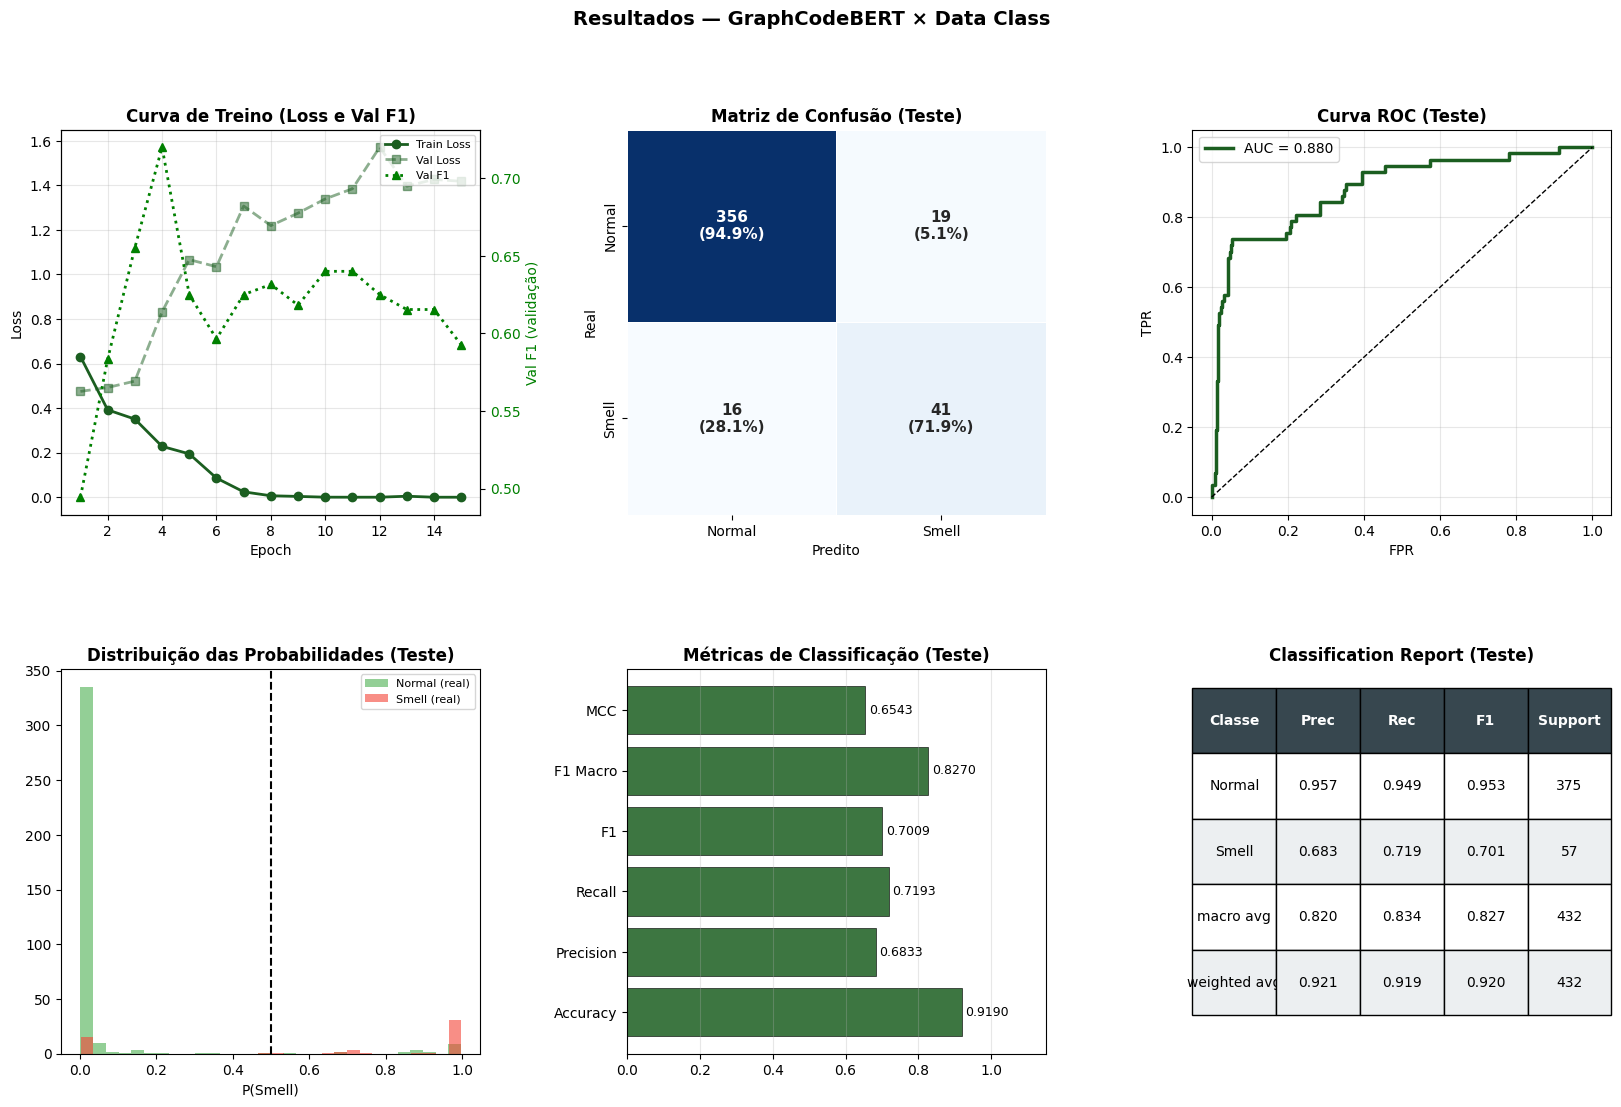

💾 Painel salvo em /kaggle/working/exp5_graphcodebert_dataclass.pdf

📋 Classification Report completo — GraphCodeBERT × Data Class
              precision    recall  f1-score   support

  Normal (0)       0.96      0.95      0.95       375
   Smell (1)       0.68      0.72      0.70        57

    accuracy                           0.92       432
   macro avg       0.82      0.83      0.83       432
weighted avg       0.92      0.92      0.92       432



In [17]:
lbl_gcb_dc, pred_gcb_dc, prob_gcb_dc = evaluate_model(model_gcb_dc, test_dl)

EXP_COLORS['GraphCodeBERT × Data Class']   = '#1B5E20'
EXP_COLORS['GraphCodeBERT × Feature Envy'] = '#66BB6A'

metrics_gcb_dc = plot_experiment(
    history    = hist_gcb_dc,
    y_true     = lbl_gcb_dc,
    y_pred     = pred_gcb_dc,
    y_prob     = prob_gcb_dc,
    exp_label  = 'GraphCodeBERT × Data Class',
    color      = EXP_COLORS['GraphCodeBERT × Data Class'],
    save_path  = f"{CONFIG['output_dir']}exp5_graphcodebert_dataclass.pdf",
)

print('\n📋 Classification Report completo — GraphCodeBERT × Data Class')
print(classification_report(lbl_gcb_dc, pred_gcb_dc, target_names=['Normal (0)','Smell (1)']))


---
## 11. EXP-6 — GraphCodeBERT × Feature Envy


In [18]:
print('═'*58)
print('  🟩 EXP-6 — GraphCodeBERT × Feature Envy')
print('═'*58)

X_tr, X_val, X_te, y_tr, y_val, y_te = split_dataset(df_fe)

train_ds = CodeSmellDataset(X_tr,  y_tr,  tok_gcb, CONFIG['max_length'])
val_ds   = CodeSmellDataset(X_val, y_val, tok_gcb, CONFIG['max_length'])
test_ds  = CodeSmellDataset(X_te,  y_te,  tok_gcb, CONFIG['max_length'])

train_dl = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True,  num_workers=0, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0, pin_memory=True)

model_gcb_fe = RobertaForSequenceClassification.from_pretrained(
    GRAPHCODEBERT_NAME, num_labels=CONFIG['num_labels'])

model_gcb_fe, hist_gcb_fe = train_model(model_gcb_fe, train_dl, val_dl, 'GraphCodeBERT×FeatureEnvy', y_tr)


══════════════════════════════════════════════════════════
  🟩 EXP-6 — GraphCodeBERT × Feature Envy
══════════════════════════════════════════════════════════
   Treino    : 1,568  (Normal=1,522 | Smell=46)
   Validação : 225  (Normal=218 | Smell=7)
   Teste     : 449  (Normal=436 | Smell=13)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/graphcodebert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  ⚖️  Class weights: Normal=0.515 | Smell=17.043
  [GraphCodeBERT×FeatureEnvy] Ep 1 | Step 50/98 | Loss 0.6415
  [GraphCodeBERT×FeatureEnvy] Ep 1/15 | TrLoss 0.6722 | ValLoss 1.2782 | ValF1 0.0000
  [GraphCodeBERT×FeatureEnvy] Ep 2 | Step 50/98 | Loss 0.9909
  [GraphCodeBERT×FeatureEnvy] Ep 2/15 | TrLoss 0.9758 | ValLoss 0.8793 | ValF1 0.0000
  [GraphCodeBERT×FeatureEnvy] Ep 3 | Step 50/98 | Loss 0.6968
  [GraphCodeBERT×FeatureEnvy] Ep 3/15 | TrLoss 0.7256 | ValLoss 0.8581 | ValF1 0.0000
  [GraphCodeBERT×FeatureEnvy] Ep 4 | Step 50/98 | Loss 0.6159
  [GraphCodeBERT×FeatureEnvy] Ep 4/15 | TrLoss 0.6975 | ValLoss 0.6282 | ValF1 0.2222  ✨ melhor ValF1!
  [GraphCodeBERT×FeatureEnvy] Ep 5 | Step 50/98 | Loss 0.3376
  [GraphCodeBERT×FeatureEnvy] Ep 5/15 | TrLoss 0.4505 | ValLoss 1.0057 | ValF1 0.1818
  [GraphCodeBERT×FeatureEnvy] Ep 6 | Step 50/98 | Loss 0.1843
  [GraphCodeBERT×FeatureEnvy] Ep 6/15 | TrLoss 0.2409 | ValLoss 1.7930 | ValF1 0.0000
  [GraphCodeBERT×FeatureEnvy] Ep 7 | Step 50/9

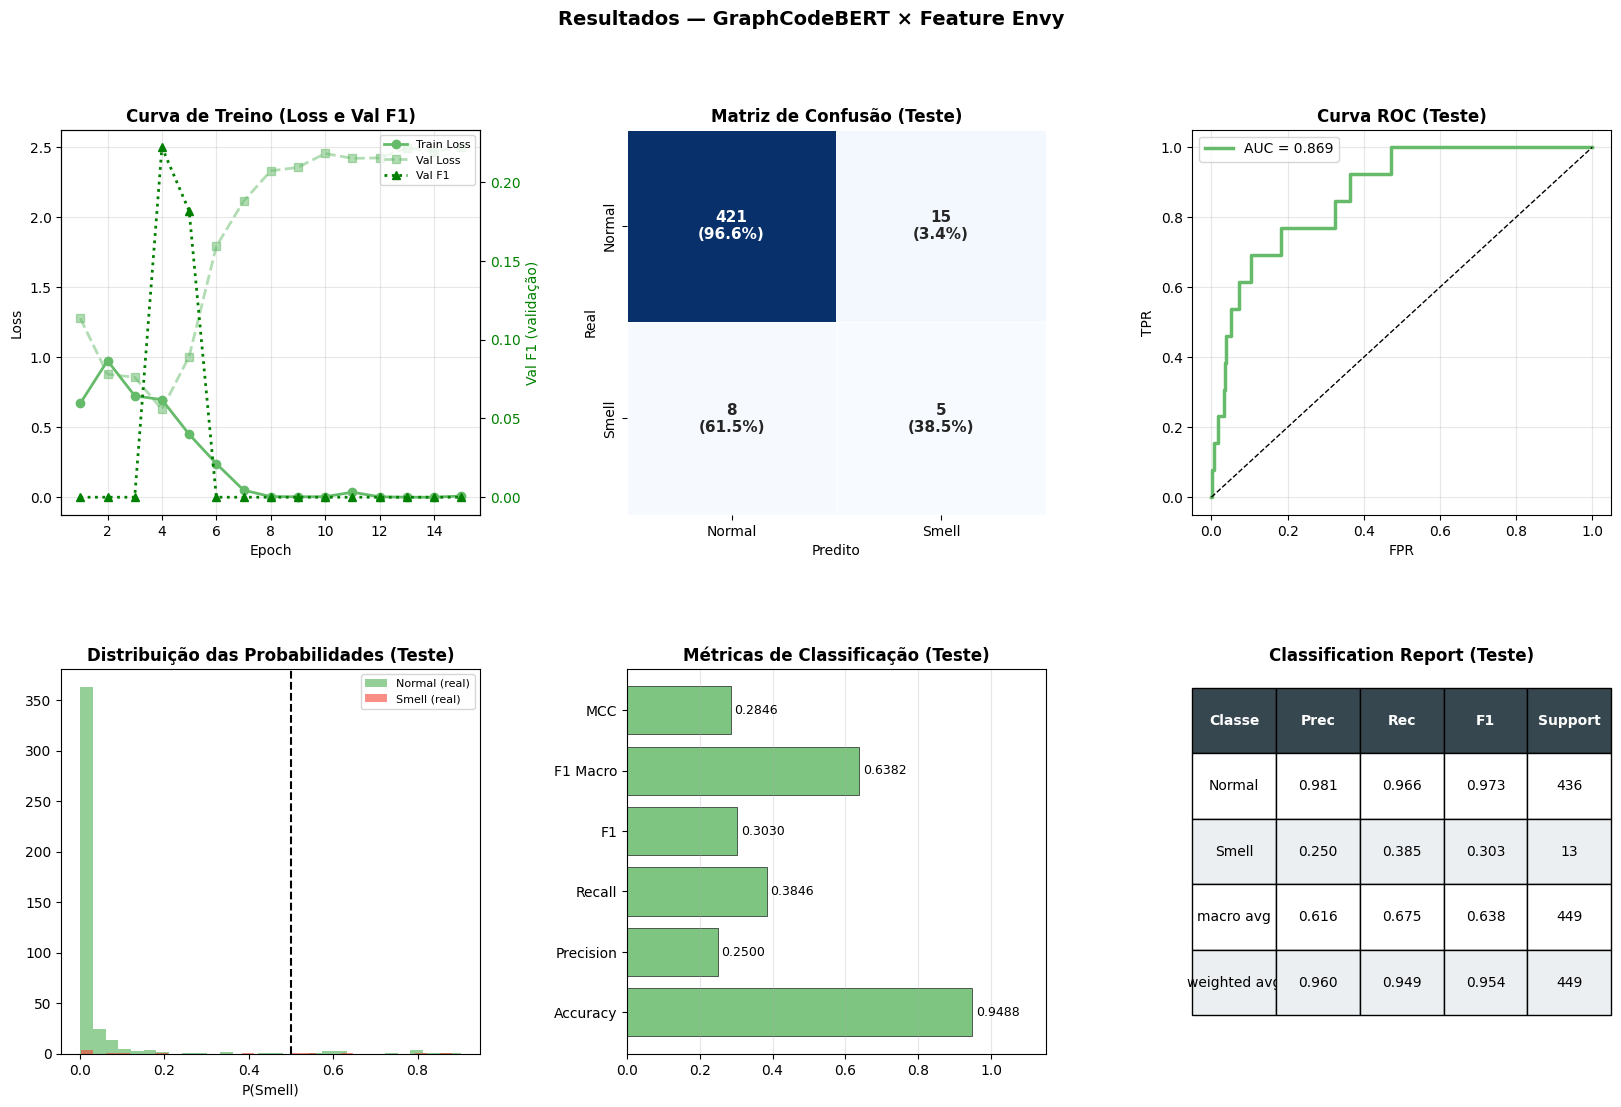

💾 Painel salvo em /kaggle/working/exp6_graphcodebert_featureenvy.pdf

📋 Classification Report completo — GraphCodeBERT × Feature Envy
              precision    recall  f1-score   support

  Normal (0)       0.98      0.97      0.97       436
   Smell (1)       0.25      0.38      0.30        13

    accuracy                           0.95       449
   macro avg       0.62      0.68      0.64       449
weighted avg       0.96      0.95      0.95       449



In [19]:
lbl_gcb_fe, pred_gcb_fe, prob_gcb_fe = evaluate_model(model_gcb_fe, test_dl)

metrics_gcb_fe = plot_experiment(
    history    = hist_gcb_fe,
    y_true     = lbl_gcb_fe,
    y_pred     = pred_gcb_fe,
    y_prob     = prob_gcb_fe,
    exp_label  = 'GraphCodeBERT × Feature Envy',
    color      = EXP_COLORS['GraphCodeBERT × Feature Envy'],
    save_path  = f"{CONFIG['output_dir']}exp6_graphcodebert_featureenvy.pdf",
)

print('\n📋 Classification Report completo — GraphCodeBERT × Feature Envy')
print(classification_report(lbl_gcb_fe, pred_gcb_fe, target_names=['Normal (0)','Smell (1)']))


---
## 12. Comparativo Final — 6 Experimentos


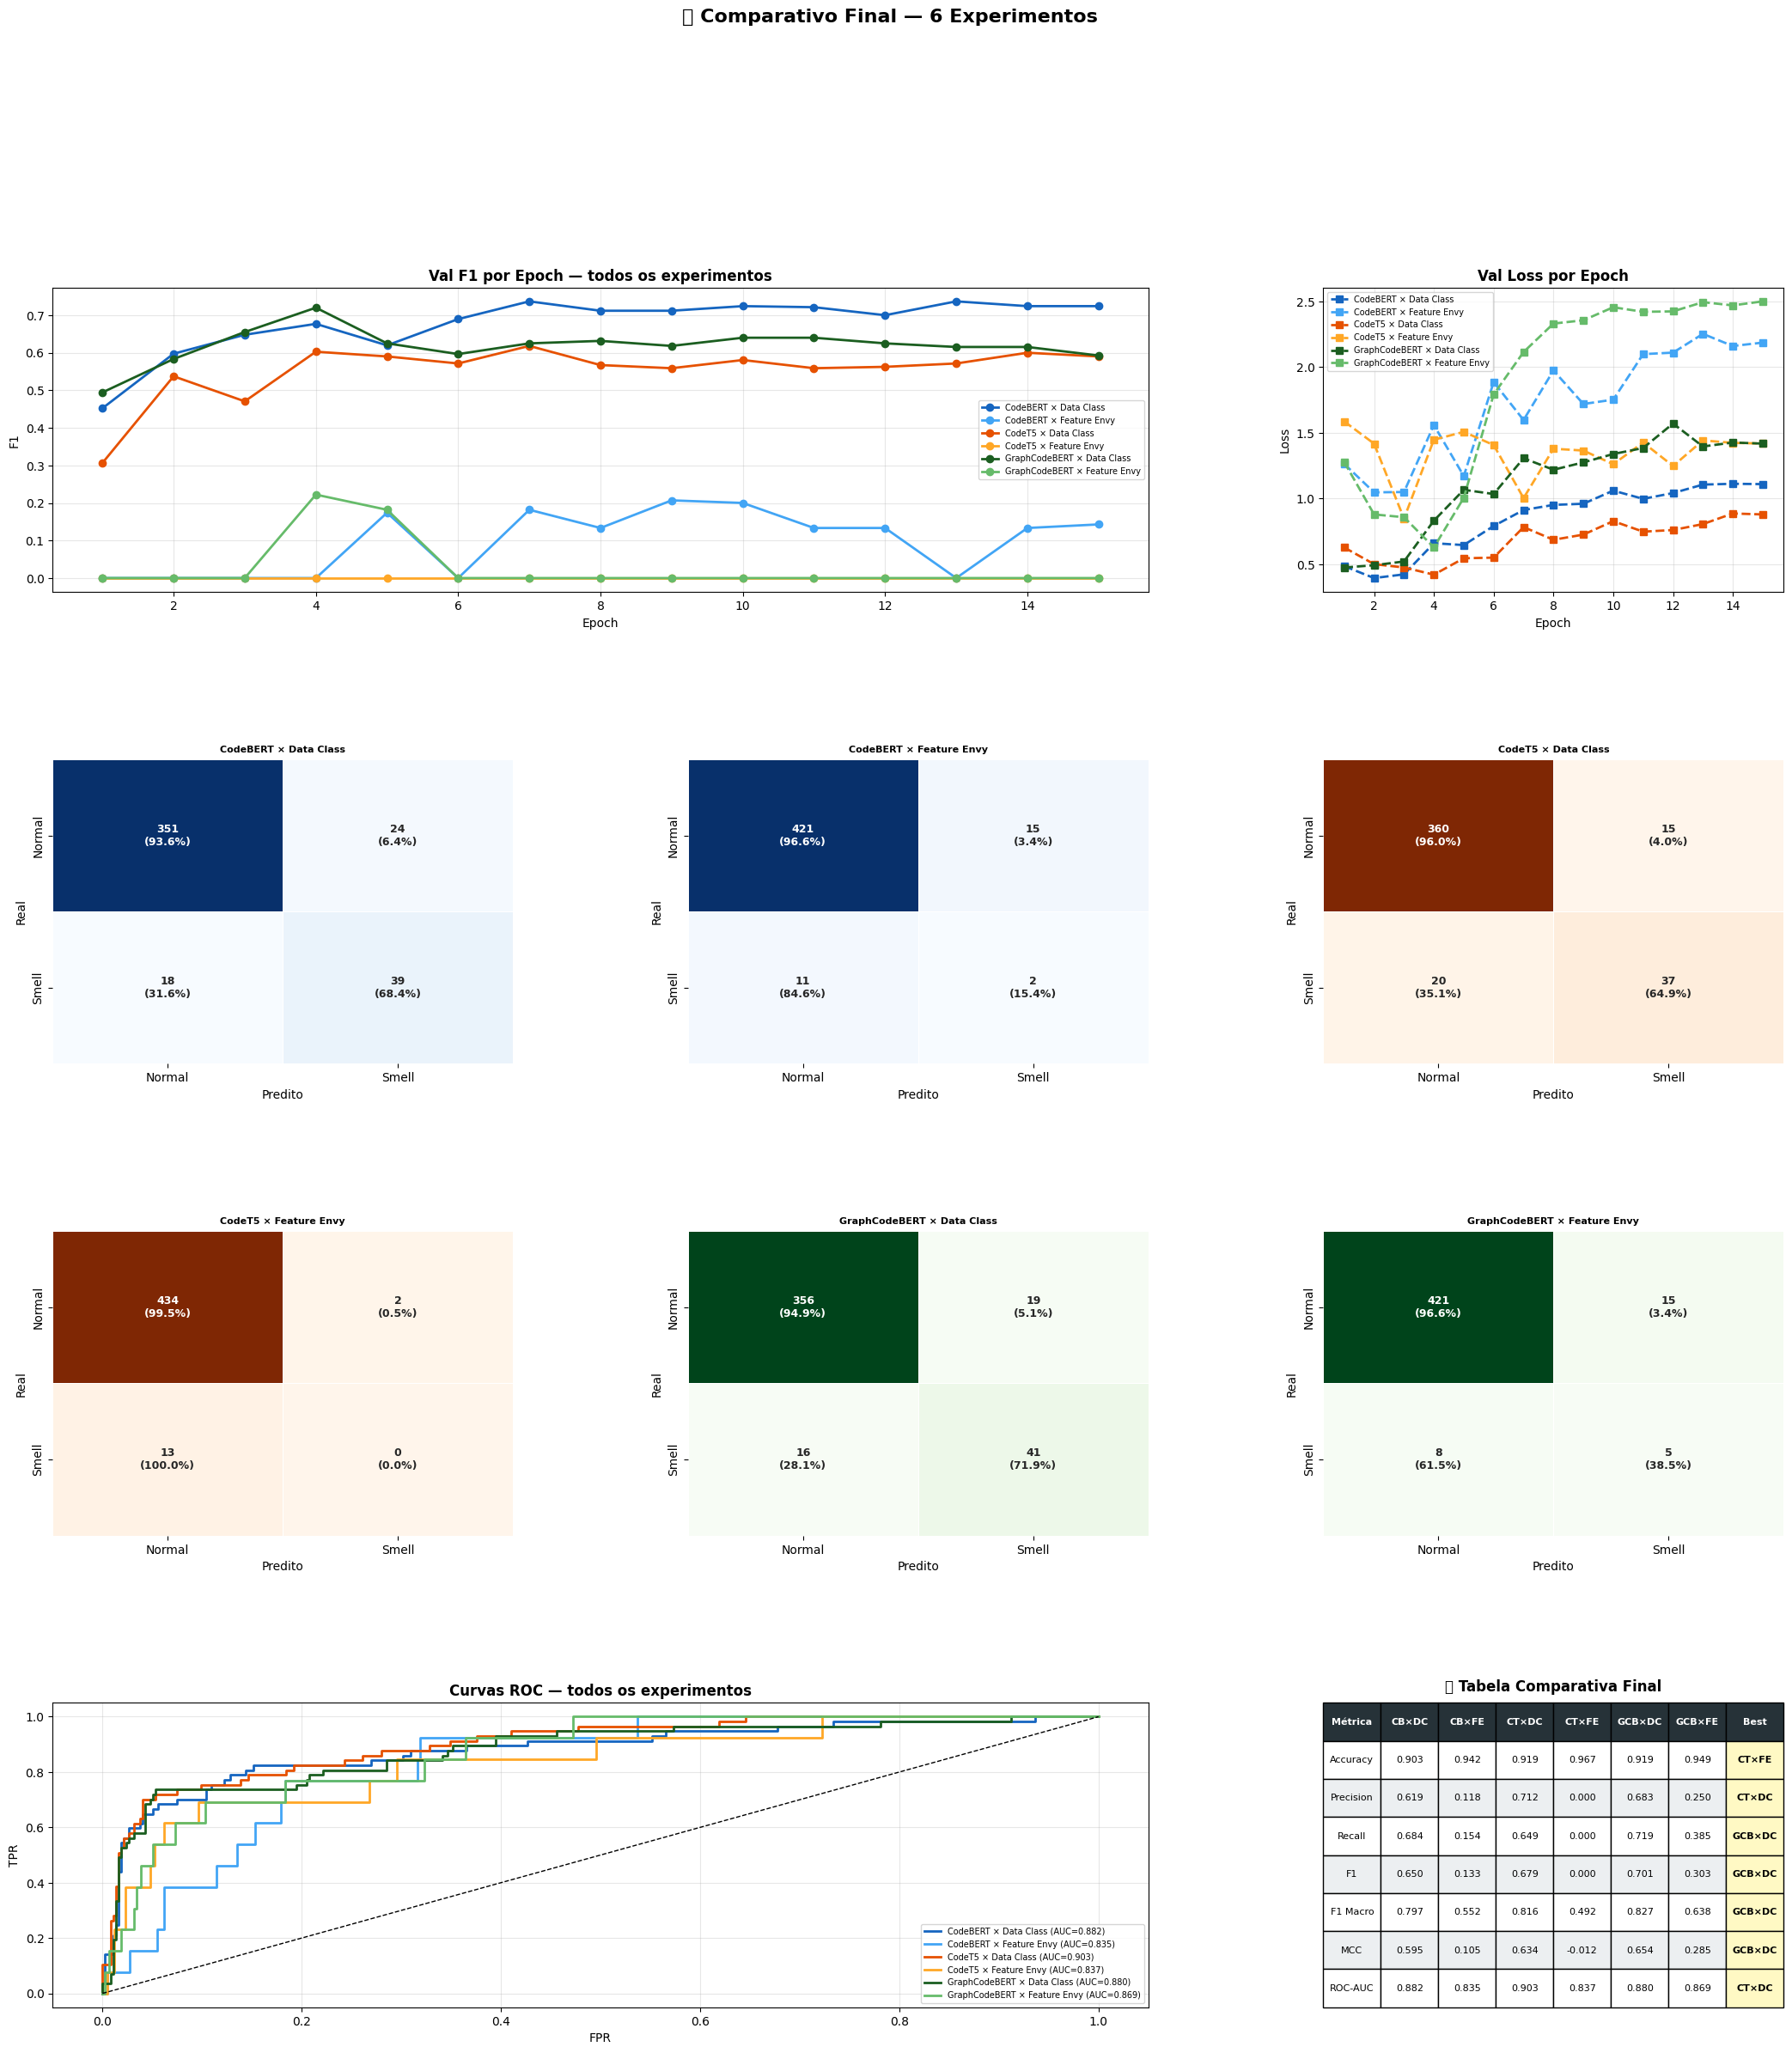

✅ Comparativo final salvo!


In [20]:
# ── Dados para o painel comparativo ──────────────────────────
EXPERIMENTS = {
    'CodeBERT × Data Class'       : (metrics_cb_dc,  hist_cb_dc,  lbl_cb_dc,  pred_cb_dc,  prob_cb_dc),
    'CodeBERT × Feature Envy'     : (metrics_cb_fe,  hist_cb_fe,  lbl_cb_fe,  pred_cb_fe,  prob_cb_fe),
    'CodeT5 × Data Class'         : (metrics_ct_dc,  hist_ct_dc,  lbl_ct_dc,  pred_ct_dc,  prob_ct_dc),
    'CodeT5 × Feature Envy'       : (metrics_ct_fe,  hist_ct_fe,  lbl_ct_fe,  pred_ct_fe,  prob_ct_fe),
    'GraphCodeBERT × Data Class'   : (metrics_gcb_dc, hist_gcb_dc, lbl_gcb_dc, pred_gcb_dc, prob_gcb_dc),
    'GraphCodeBERT × Feature Envy' : (metrics_gcb_fe, hist_gcb_fe, lbl_gcb_fe, pred_gcb_fe, prob_gcb_fe),
}

fig = plt.figure(figsize=(26, 26))
fig.suptitle('🏆 Comparativo Final — 6 Experimentos', fontsize=16, fontweight='bold', y=1.005)
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.55, wspace=0.38)

# ── Linha 1: Curvas de Treino (Val F1 por epoch) ─────────────────
ax_train = fig.add_subplot(gs[0, :2])
for exp, (_, hist, *_) in EXPERIMENTS.items():
    epochs = range(1, len(hist['val_f1']) + 1)
    ax_train.plot(epochs, hist['val_f1'], 'o-', color=EXP_COLORS[exp],
                  linewidth=2, label=exp)
ax_train.set_title('Val F1 por Epoch — todos os experimentos', fontweight='bold')
ax_train.set_xlabel('Epoch'); ax_train.set_ylabel('F1')
ax_train.legend(fontsize=7); ax_train.grid(True, alpha=0.3)

# ── Linha 1: Val Loss ─────────────────────────────────────────
ax_loss = fig.add_subplot(gs[0, 2])
for exp, (_, hist, *_) in EXPERIMENTS.items():
    epochs = range(1, len(hist['val_loss']) + 1)
    ax_loss.plot(epochs, hist['val_loss'], 's--', color=EXP_COLORS[exp],
                 linewidth=2, label=exp)
ax_loss.set_title('Val Loss por Epoch', fontweight='bold')
ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Loss')
ax_loss.legend(fontsize=7); ax_loss.grid(True, alpha=0.3)

# ── Linhas 2-3: Matrizes de Confusão (6 painéis, 3 por linha) ────────────────
exp_list = list(EXPERIMENTS.items())
for idx, (exp, (_, _, y_true, y_pred, _)) in enumerate(exp_list):
    row_i = 1 + idx // 3
    col_i = idx % 3
    ax = fig.add_subplot(gs[row_i, col_i])
    cm     = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1)[:,np.newaxis] * 100
    annot  = np.array([[f'{cm[i,j]}\n({cm_pct[i,j]:.1f}%)' for j in range(2)] for i in range(2)])
    if 'GraphCodeBERT' in exp:
        cmap = plt.cm.Greens
    elif 'CodeBERT' in exp:
        cmap = plt.cm.Blues
    else:
        cmap = plt.cm.Oranges
    sns.heatmap(cm, annot=annot, fmt='', ax=ax, cmap=cmap,
                xticklabels=['Normal','Smell'], yticklabels=['Normal','Smell'],
                linewidths=0.5, cbar=False, annot_kws={'size':9,'weight':'bold'})
    ax.set_title(exp, fontweight='bold', fontsize=8)
    ax.set_xlabel('Predito'); ax.set_ylabel('Real')

# ── Linha 4: Curvas ROC sobrepostas + Tabela comparativa ─────
ax_roc = fig.add_subplot(gs[3, :2])
for exp, (_, _, y_true, _, y_prob) in EXPERIMENTS.items():
    try:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc_val     = roc_auc_score(y_true, y_prob)
        ax_roc.plot(fpr, tpr, color=EXP_COLORS[exp], linewidth=2,
                    label=f'{exp} (AUC={auc_val:.3f})')
    except Exception:
        pass
ax_roc.plot([0,1],[0,1],'k--', linewidth=1)
ax_roc.set_title('Curvas ROC — todos os experimentos', fontweight='bold')
ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
ax_roc.legend(fontsize=7); ax_roc.grid(True, alpha=0.3)

# ── Tabela resumo final ───────────────────────────────────────
ax_tbl = fig.add_subplot(gs[3, 2])
ax_tbl.axis('off')

met_keys = ['accuracy','precision','recall','f1','f1_macro','mcc','roc_auc']
met_lbls = ['Accuracy','Precision','Recall','F1','F1 Macro','MCC','ROC-AUC']

col_labels = ['Métrica', 'CB×DC', 'CB×FE', 'CT×DC', 'CT×FE', 'GCB×DC', 'GCB×FE', 'Best']
exp_order  = list(EXPERIMENTS.keys())
short_keys = ['CB×DC', 'CB×FE', 'CT×DC', 'CT×FE', 'GCB×DC', 'GCB×FE']

table_rows = []
for lbl, key in zip(met_lbls, met_keys):
    vals   = [EXPERIMENTS[e][0].get(key, float('nan')) for e in exp_order]
    best_i = int(np.nanargmax(vals))
    row    = [lbl] + [f'{v:.3f}' if not np.isnan(v) else 'N/A' for v in vals] + [short_keys[best_i]]
    table_rows.append(row)

tbl = ax_tbl.table(
    cellText  = table_rows,
    colLabels = col_labels,
    cellLoc   = 'center',
    loc       = 'center',
    bbox      = [0.0, 0.0, 1.0, 1.0],
)
tbl.auto_set_font_size(False); tbl.set_fontsize(8)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#263238')
        cell.set_text_props(color='white', fontweight='bold')
    elif col == 7 and row > 0:  # Coluna Best
        cell.set_facecolor('#FFF9C4')
        cell.set_text_props(fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#ECEFF1')
ax_tbl.set_title('📋 Tabela Comparativa Final', fontweight='bold', pad=10)

plt.savefig(f"{CONFIG['output_dir']}comparativo_final.png", dpi=150, bbox_inches='tight')
plt.show()
print('✅ Comparativo final salvo!')


In [21]:
# ── Resumo em texto no console ────────────────────────────────
exp_labels_short = {
    'CodeBERT × Data Class'       : 'CB×DC',
    'CodeBERT × Feature Envy'     : 'CB×FE',
    'CodeT5 × Data Class'         : 'CT×DC',
    'CodeT5 × Feature Envy'       : 'CT×FE',
    'GraphCodeBERT × Data Class'  : 'GCB×DC',
    'GraphCodeBERT × Feature Envy': 'GCB×FE',
}

met_keys = ['accuracy','precision','recall','f1','f1_macro','mcc','roc_auc']
met_lbls = ['Accuracy','Precision','Recall','F1','F1 Macro','MCC','ROC-AUC']
short_keys = list(exp_labels_short.values())
exp_order  = list(EXPERIMENTS.keys())

print('\n' + '═'*85)
print(f'  {"RESUMO FINAL — 6 EXPERIMENTOS":^81}')
print('═'*85)
print(f'  {"Métrica":<16} {"CB×DC":>8} {"CB×FE":>8} {"CT×DC":>8} {"CT×FE":>8} {"GCB×DC":>8} {"GCB×FE":>8}  {"Melhor"}')
print('─'*85)
for lbl, key in zip(met_lbls, met_keys):
    vals    = [EXPERIMENTS[e][0].get(key, float('nan')) for e in exp_order]
    best_i  = int(np.nanargmax(vals))
    row_str = f'  {lbl:<16}'
    for i, v in enumerate(vals):
        mark = ' ◀' if i == best_i else '  '
        row_str += f' {v:>7.4f}{mark}' if not np.isnan(v) else f'  {"N/A":>6}  '
    print(row_str + f'  {short_keys[best_i]}')
print('═'*85)
print('  CB=CodeBERT  CT=CodeT5  GCB=GraphCodeBERT  DC=Data Class  FE=Feature Envy  ◀=melhor')



═════════════════════════════════════════════════════════════════════════════════════
                            RESUMO FINAL — 6 EXPERIMENTOS                          
═════════════════════════════════════════════════════════════════════════════════════
  Métrica             CB×DC    CB×FE    CT×DC    CT×FE   GCB×DC   GCB×FE  Melhor
─────────────────────────────────────────────────────────────────────────────────────
  Accuracy          0.9028    0.9421    0.9190    0.9666 ◀  0.9190    0.9488    CT×FE
  Precision         0.6190    0.1176    0.7115 ◀  0.0000    0.6833    0.2500    CT×DC
  Recall            0.6842    0.1538    0.6491    0.0000    0.7193 ◀  0.3846    GCB×DC
  F1                0.6500    0.1333    0.6789    0.0000    0.7009 ◀  0.3030    GCB×DC
  F1 Macro          0.7968    0.5517    0.8163    0.4915    0.8270 ◀  0.6382    GCB×DC
  MCC               0.5947    0.1049    0.6335   -0.0116    0.6543 ◀  0.2846    GCB×DC
  ROC-AUC           0.8816    0.8347    0.9035 ◀  0.8373

## 13. Salvamento dos Modelos e Resultados


In [22]:
save_map = {
    'codebert_dataclass'        : (model_cb_dc,  tok_cb),
    'codebert_featureenvy'      : (model_cb_fe,  tok_cb),
    'codet5_dataclass'          : (model_ct_dc,  tok_ct),
    'codet5_featureenvy'        : (model_ct_fe,  tok_ct),
    'graphcodebert_dataclass'   : (model_gcb_dc, tok_gcb),
    'graphcodebert_featureenvy' : (model_gcb_fe, tok_gcb),
}

for folder_name, (model, tokenizer) in save_map.items():
    save_path = f"{CONFIG['output_dir']}{folder_name}"
    model.save_pretrained(save_path)
    tokenizer.save_pretrained(save_path)
    print(f'  💾 Salvo: {save_path}')

# JSON com todas as métricas
all_results = {}
for exp, (metrics, _, *_) in EXPERIMENTS.items():
    all_results[exp] = {k: round(float(v), 6) for k, v in metrics.items()}
all_results['config'] = {k: str(v) for k, v in CONFIG.items()}

json_path = f"{CONFIG['output_dir']}all_results.json"
with open(json_path, 'w') as f:
    json.dump(all_results, f, indent=2)

print(f'\n  📄 Métricas JSON: {json_path}')
print('\n✅ Tudo salvo com sucesso!')


  💾 Salvo: /kaggle/working/codebert_dataclass
  💾 Salvo: /kaggle/working/codebert_featureenvy
  💾 Salvo: /kaggle/working/codet5_dataclass
  💾 Salvo: /kaggle/working/codet5_featureenvy
  💾 Salvo: /kaggle/working/graphcodebert_dataclass
  💾 Salvo: /kaggle/working/graphcodebert_featureenvy

  📄 Métricas JSON: /kaggle/working/all_results.json

✅ Tudo salvo com sucesso!
